# Rolling-Origin Backtest

**Purpose:** Verify that the ML advantage over the Naïve baseline is *robust across time*, not an artefact of one particular test split.

**Design:**
- **52 weekly origins** — the last 52 weeks of the dataset (Oct 2019 → Sep 2020)
- At each origin *t*, LightGBM is re-trained on all available data *before* week *t*, then used to predict week *t* for all articles (true one-step-ahead forecast with no look-ahead)
- Naïve, MA-4 and Croston are also evaluated at each origin using only history available before *t*
- Metrics are computed per origin, then summarised across all 52 origins

**Key question:** Does the ML model consistently beat the Naïve baseline at every origin, including during the COVID shock (March 2020)?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
import lightgbm as lgb
import warnings
import os
import time

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
os.makedirs('plots/rolling', exist_ok=True)

BASE      = '/Users/kamilaya/Desktop/thesis'
TRAIN_END = '2019-04-30'   # original train/val boundary (kept for reference only)


In [2]:
# ── Load preprocessed (unscaled) full grid ────────────────────────────────────
# Tree models are scale-invariant; retraining on raw features avoids
# refitting a scaler at every origin (which would be correct but slow).
df = pd.read_csv(f'{BASE}/tshirts_preprocessed.csv', parse_dates=['week_start'])
df = df.sort_values(['article_id', 'week_start']).reset_index(drop=True)

weeks = sorted(df['week_start'].unique())
print(f'Dataset: {df.shape}   |   {len(weeks)} weeks  '
      f'({weeks[0].date()} → {weeks[-1].date()})')

# ── Feature set (all pre-computed, no scaling required) ───────────────────────
OHE_COLS = [c for c in df.columns if any(c.startswith(p) for p in
            ('index_group_name_', 'colour_group_name_',
             'graphical_appearance_name_', 'perceived_colour_value_name_'))]

BASE_FEATS = ['avg_weekly_price', 'real_price', 'price_vs_median',
              'week_of_year', 'month', 'quarter',
              'is_spring_summer', 'is_sale_season',
              'product_age_weeks',
              'sales_lag1', 'sales_lag2', 'sales_lag4',
              'sales_rolling4_mean', 'sales_rolling4_std'] + OHE_COLS

if 'covid' in df.columns:
    BASE_FEATS = ['covid'] + BASE_FEATS

FEATURES = [f for f in BASE_FEATS if f in df.columns]
TARGET   = 'log_sales_volume'
print(f'Features: {len(FEATURES)}')


Dataset: (834538, 113)   |   106 weeks  (2018-09-17 → 2020-09-21)
Features: 97


In [3]:
# ── Metric helpers ────────────────────────────────────────────────────────────
def rmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(np.sqrt(np.mean((a - np.clip(b, 0, None)) ** 2)))

def mae(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(np.mean(np.abs(a - np.clip(b, 0, None))))

def nz_mape(a, b):
    a, b = np.asarray(a, float), np.clip(np.asarray(b, float), 0, None)
    m = a > 0
    return float(np.mean(np.abs((a[m] - b[m]) / a[m])) * 100) if m.sum() else np.nan

# ── Croston per-article fit (same implementation as baselines.ipynb) ──────────
def croston_fit(series, alpha=0.1, beta=0.1):
    series = np.asarray(series, float)
    nz = np.where(series > 0)[0]
    if len(nz) == 0: return 0.0, 1.0
    z, p = series[nz[0]], float(nz[0] + 1)
    for k in range(1, len(nz)):
        z = alpha * series[nz[k]] + (1 - alpha) * z
        p = beta  * (nz[k] - nz[k-1]) + (1 - beta) * p
    return z, p

def croston_predict(train_data, pred_articles):
    fc = {}
    for aid, grp in train_data.groupby('article_id'):
        z, p = croston_fit(grp.sort_values('week_start')['weekly_sales_volume'].values)
        fc[aid] = z / p if p > 0 else 0.0
    gm = train_data['weekly_sales_volume'].mean()
    return np.clip(
        pred_articles.map(lambda a: fc.get(a, gm)).fillna(gm).values, 0, None)


In [4]:
# ── Rolling-origin loop — 52 weekly origins ───────────────────────────────────
EVAL_WEEKS = weeks[-52:]   # Oct 2019 → Sep 2020
COVID_WEEK = pd.Timestamp('2020-03-01')

lgb_params = dict(n_estimators=100, learning_rate=0.1, num_leaves=63,
                  min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                  random_state=42, verbose=-1)

results = []   # one dict per origin
t_start = time.time()

for i, origin in enumerate(EVAL_WEEKS):
    train_mask = df['week_start'] < origin
    pred_mask  = df['week_start'] == origin

    train_data = df[train_mask]
    pred_data  = df[pred_mask]

    y_true = pred_data['weekly_sales_volume'].values

    # ── Naïve: last week's actual sales (sales_lag1 already encodes this) ──
    naive_pred  = pred_data['sales_lag1'].values

    # ── MA-4: rolling 4-week mean ──────────────────────────────────────────
    ma4_pred    = pred_data['sales_rolling4_mean'].values

    # ── Croston ────────────────────────────────────────────────────────────
    croston_pred = croston_predict(train_data, pred_data['article_id'])

    # ── LightGBM: retrain from scratch on expanding window ─────────────────
    X_tr = train_data[FEATURES]
    y_tr = train_data[TARGET]
    X_pr = pred_data[FEATURES]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_tr, y_tr)
    lgb_pred = np.expm1(np.clip(model.predict(X_pr), 0, None))

    results.append({
        'origin':       origin,
        'is_covid':     origin >= COVID_WEEK,
        'n_articles':   len(pred_data),
        'zero_pct':     round((y_true == 0).mean() * 100, 1),
        # ── per-origin RMSE ─────────────────────────────────────────────────
        'RMSE_naive':   rmse(y_true, naive_pred),
        'RMSE_ma4':     rmse(y_true, ma4_pred),
        'RMSE_croston': rmse(y_true, croston_pred),
        'RMSE_lgb':     rmse(y_true, lgb_pred),
        # ── per-origin MAE ──────────────────────────────────────────────────
        'MAE_naive':    mae(y_true, naive_pred),
        'MAE_lgb':      mae(y_true, lgb_pred),
        # ── per-origin NZ-MAPE ──────────────────────────────────────────────
        'MAPE_naive':   nz_mape(y_true, naive_pred),
        'MAPE_lgb':     nz_mape(y_true, lgb_pred),
    })

    elapsed = time.time() - t_start
    eta     = elapsed / (i + 1) * (len(EVAL_WEEKS) - i - 1)
    print(f'  [{i+1:2d}/52]  {origin.date()}  '
          f'RMSE naive={results[-1]["RMSE_naive"]:.3f}  '
          f'lgb={results[-1]["RMSE_lgb"]:.3f}  '
          f'(ETA {eta:.0f}s)', end='\r')

print(f'\nDone in {time.time()-t_start:.1f}s')
res = pd.DataFrame(results)


  [52/52]  2020-09-21  RMSE naive=7.292  lgb=6.473  (ETA 0s))))
Done in 133.4s


In [5]:
# ── Per-method summary across all 52 origins ─────────────────────────────────
methods = ['naive', 'ma4', 'croston', 'lgb']
labels  = ['Naïve', 'MA-4', 'Croston', 'LightGBM (rolling retrain)']

print('='*72)
print('  ROLLING-ORIGIN SUMMARY  —  52 weekly origins (Oct 2019 → Sep 2020)')
print('='*72)
for m, lab in zip(methods, labels):
    col = f'RMSE_{m}'
    avg, med = res[col].mean(), res[col].median()
    print(f'  {lab:35s}  mean RMSE={avg:.4f}   median={med:.4f}')

print()
# ML win rate (% of origins where LightGBM RMSE < Naïve RMSE)
lgb_wins     = (res['RMSE_lgb'] < res['RMSE_naive']).sum()
lgb_win_rate = lgb_wins / len(res) * 100
print(f'  LightGBM beats Naïve in {lgb_wins}/52 origins  ({lgb_win_rate:.0f}% win rate)')

# Pre-/post-COVID split
pre  = res[~res['is_covid']]
post = res[ res['is_covid']]
print(f'\n  Pre-COVID  ({len(pre):2d} origins):  '
      f'mean RMSE naive={pre["RMSE_naive"].mean():.4f}   lgb={pre["RMSE_lgb"].mean():.4f}   '
      f'Δ={(pre["RMSE_lgb"].mean()-pre["RMSE_naive"].mean())/pre["RMSE_naive"].mean()*100:+.1f}%')
print(f'  COVID period ({len(post):2d} origins):  '
      f'mean RMSE naive={post["RMSE_naive"].mean():.4f}   lgb={post["RMSE_lgb"].mean():.4f}   '
      f'Δ={(post["RMSE_lgb"].mean()-post["RMSE_naive"].mean())/post["RMSE_naive"].mean()*100:+.1f}%')

res['delta_pct'] = (res['RMSE_lgb'] - res['RMSE_naive']) / res['RMSE_naive'] * 100
res.to_csv(f'{BASE}/rolling_backtest_results.csv', index=False)
print('\nSaved: rolling_backtest_results.csv')


  ROLLING-ORIGIN SUMMARY  —  52 weekly origins (Oct 2019 → Sep 2020)
  Naïve                                mean RMSE=5.7561   median=5.8127
  MA-4                                 mean RMSE=6.7263   median=6.2608
  Croston                              mean RMSE=10.0347   median=9.2309
  LightGBM (rolling retrain)           mean RMSE=5.3238   median=5.1675

  LightGBM beats Naïve in 38/52 origins  (73% win rate)

  Pre-COVID  (22 origins):  mean RMSE naive=4.0969   lgb=3.7302   Δ=-9.0%
  COVID period (30 origins):  mean RMSE naive=6.9728   lgb=6.4925   Δ=-6.9%

Saved: rolling_backtest_results.csv


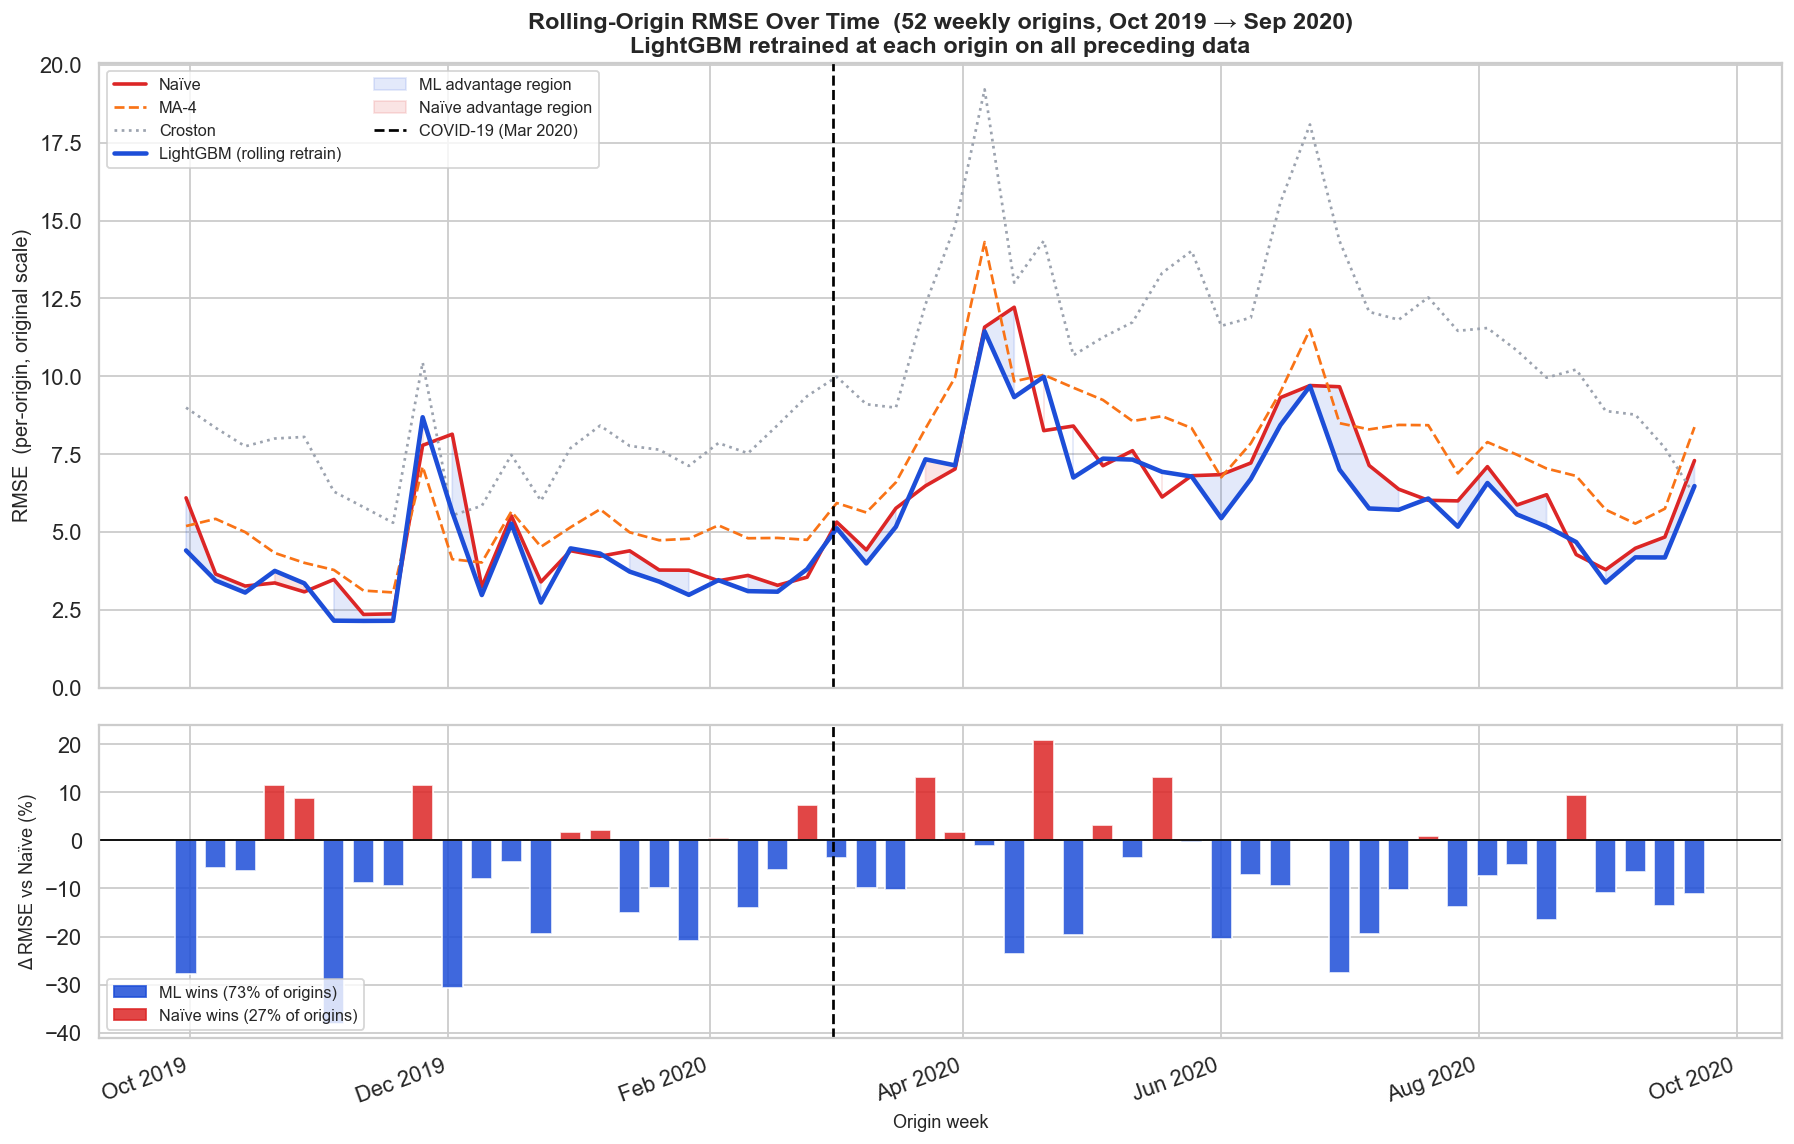

Saved: plots/rolling/R1_rmse_over_time.png


In [6]:
# ── Plot 1: Per-origin RMSE over time ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

ax = axes[0]
ax.plot(res['origin'], res['RMSE_naive'],   color='#dc2626', lw=2,    label='Naïve')
ax.plot(res['origin'], res['RMSE_ma4'],     color='#f97316', lw=1.5,  label='MA-4',    linestyle='--')
ax.plot(res['origin'], res['RMSE_croston'], color='#9ca3af', lw=1.5,  label='Croston', linestyle=':')
ax.plot(res['origin'], res['RMSE_lgb'],     color='#1d4ed8', lw=2.5,  label='LightGBM (rolling retrain)')

ax.fill_between(res['origin'], res['RMSE_lgb'], res['RMSE_naive'],
                where=res['RMSE_lgb'] < res['RMSE_naive'],
                alpha=0.12, color='#1d4ed8', label='ML advantage region')
ax.fill_between(res['origin'], res['RMSE_lgb'], res['RMSE_naive'],
                where=res['RMSE_lgb'] >= res['RMSE_naive'],
                alpha=0.12, color='#dc2626', label='Naïve advantage region')

ax.axvline(COVID_WEEK, color='black', lw=1.5, linestyle='--', label='COVID-19 (Mar 2020)')
ax.set_ylabel('RMSE  (per-origin, original scale)', fontsize=11)
ax.set_title('Rolling-Origin RMSE Over Time  (52 weekly origins, Oct 2019 → Sep 2020)\n'
             'LightGBM retrained at each origin on all preceding data',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.set_ylim(bottom=0)

# Bottom panel: Δ RMSE (LightGBM vs Naïve) — negative = ML wins
ax2 = axes[1]
colors_bar = ['#1d4ed8' if v < 0 else '#dc2626' for v in res['delta_pct']]
ax2.bar(res['origin'], res['delta_pct'], width=5, color=colors_bar, alpha=0.85)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(COVID_WEEK, color='black', lw=1.5, linestyle='--')
ax2.set_ylabel('Δ RMSE vs Naïve (%)', fontsize=10)
ax2.set_xlabel('Origin week', fontsize=10)

# Annotate win rate
win_patch = mpatches.Patch(color='#1d4ed8', alpha=0.85,
                           label=f'ML wins ({lgb_win_rate:.0f}% of origins)')
lose_patch = mpatches.Patch(color='#dc2626', alpha=0.85,
                            label=f'Naïve wins ({100-lgb_win_rate:.0f}% of origins)')
ax2.legend(handles=[win_patch, lose_patch], fontsize=9, loc='lower left')

for ax_i in axes:
    ax_i.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_i.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('plots/rolling/R1_rmse_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/rolling/R1_rmse_over_time.png')


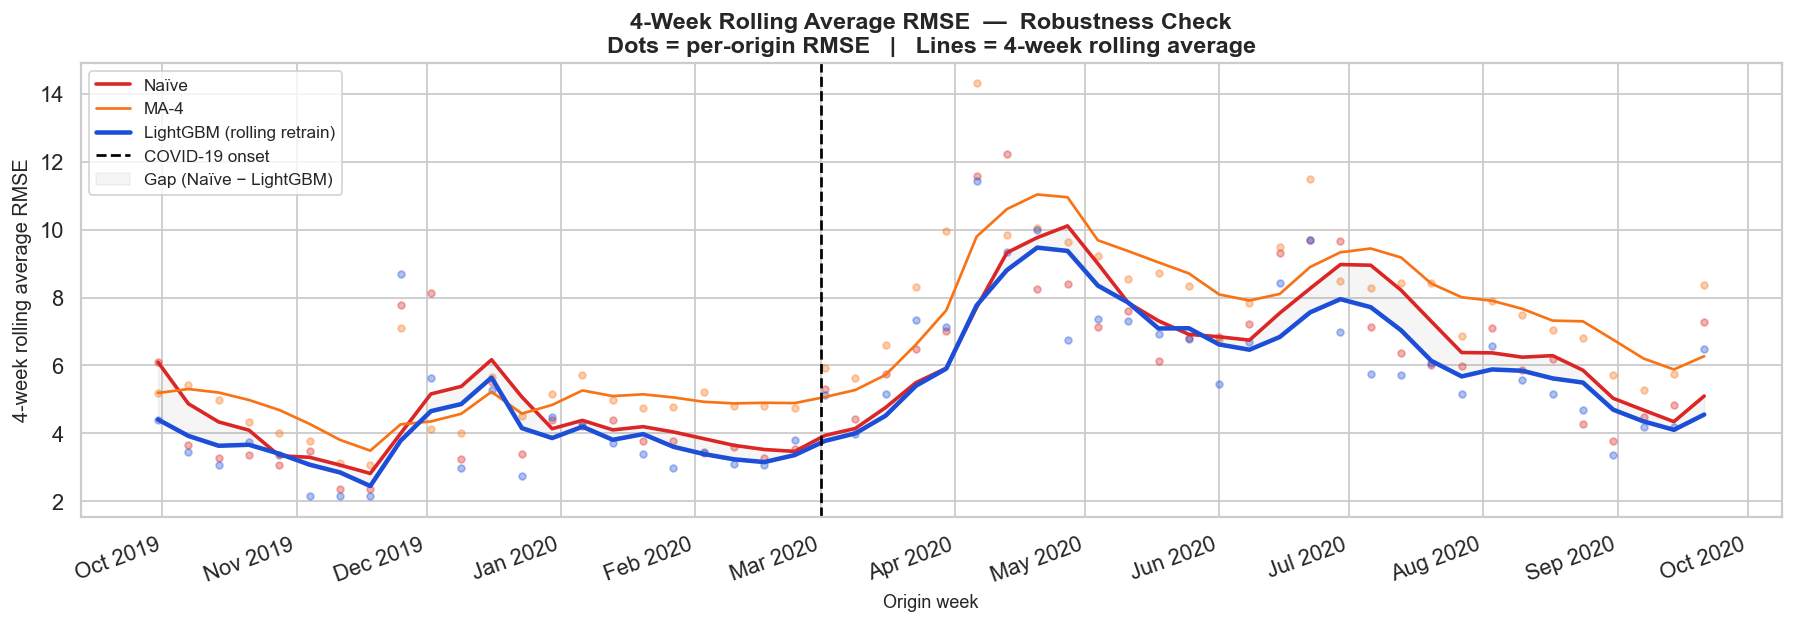

Saved: plots/rolling/R2_rolling_avg_rmse.png


In [7]:
# ── Plot 2: 4-week rolling average RMSE — smoothed trend ─────────────────────
roll = res.set_index('origin').sort_index()

fig, ax = plt.subplots(figsize=(14, 5))

for col, label, color, lw in [
    ('RMSE_naive',   'Naïve',                         '#dc2626', 2.0),
    ('RMSE_ma4',     'MA-4',                           '#f97316', 1.5),
    ('RMSE_lgb',     'LightGBM (rolling retrain)',     '#1d4ed8', 2.5),
]:
    smoothed = roll[col].rolling(4, min_periods=1).mean()
    ax.plot(smoothed.index, smoothed, color=color, lw=lw, label=label)
    # Also show raw as semi-transparent dots
    ax.scatter(roll.index, roll[col], color=color, s=14, alpha=0.35)

ax.axvline(COVID_WEEK, color='black', lw=1.5, linestyle='--', label='COVID-19 onset')
ax.fill_between(roll.index,
                roll['RMSE_lgb'].rolling(4, min_periods=1).mean(),
                roll['RMSE_naive'].rolling(4, min_periods=1).mean(),
                alpha=0.08, color='grey', label='Gap (Naïve − LightGBM)')

ax.set_ylabel('4-week rolling average RMSE', fontsize=11)
ax.set_xlabel('Origin week', fontsize=10)
ax.set_title('4-Week Rolling Average RMSE  —  Robustness Check\n'
             'Dots = per-origin RMSE   |   Lines = 4-week rolling average',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9.5, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plots/rolling/R2_rolling_avg_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/rolling/R2_rolling_avg_rmse.png')


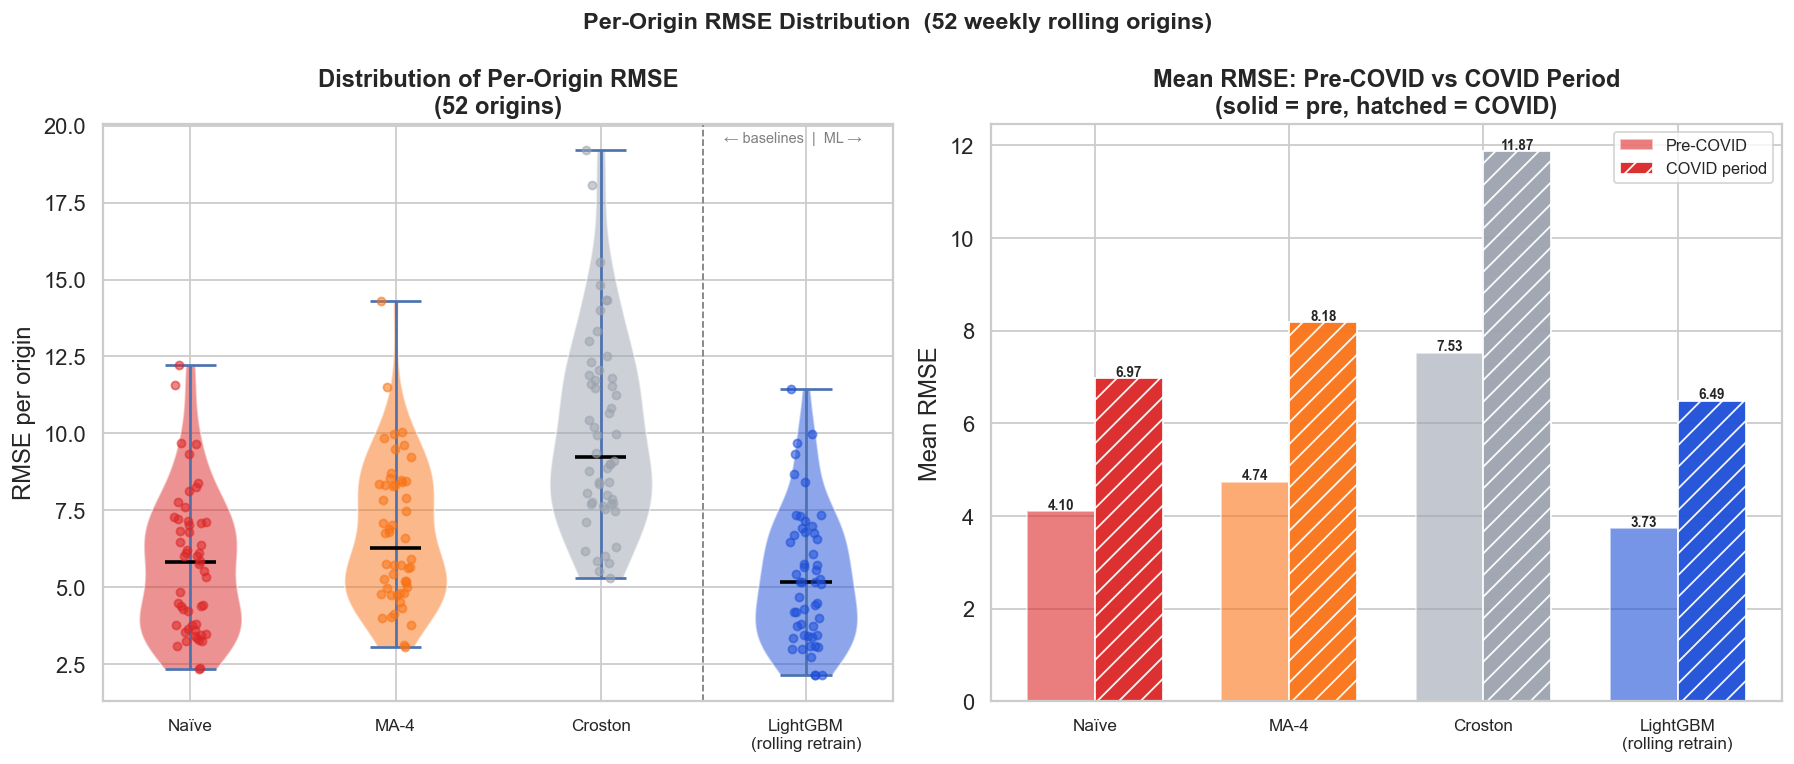

Saved: plots/rolling/R3_rmse_distribution.png


In [8]:
# ── Plot 3: Distribution of per-origin RMSE across all 52 origins ─────────────
plot_methods = {
    'Naïve':                      ('RMSE_naive',   '#dc2626'),
    'MA-4':                       ('RMSE_ma4',     '#f97316'),
    'Croston':                    ('RMSE_croston', '#9ca3af'),
    'LightGBM\n(rolling retrain)': ('RMSE_lgb',    '#1d4ed8'),
}

data_vals = [res[col].values for _, (col, _) in plot_methods.items()]
colors    = [c for _, (_, c) in plot_methods.items()]
labels    = list(plot_methods.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: violin + swarm
vp = axes[0].violinplot(data_vals, positions=range(len(labels)),
                         showmedians=True, showextrema=True)
for i, (body, col) in enumerate(zip(vp['bodies'], colors)):
    body.set_facecolor(col); body.set_alpha(0.5)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)

# Overlay individual origin dots
for i, (vals, col) in enumerate(zip(data_vals, colors)):
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(vals))
    axes[0].scatter(np.full(len(vals), i) + jitter, vals,
                   color=col, s=20, alpha=0.55, zorder=3)

axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, fontsize=9.5)
axes[0].set_ylabel('RMSE per origin'); axes[0].set_title('Distribution of Per-Origin RMSE\n(52 origins)', fontweight='bold')
axes[0].axvline(2.5, color='grey', lw=1, linestyle='--')
axes[0].text(2.6, axes[0].get_ylim()[1]*0.97, '← baselines  |  ML →', fontsize=8, color='grey')

# Right: pre-COVID vs COVID breakdown (grouped bars)
pre_means  = [res[~res['is_covid']][col].mean() for _, (col, _) in plot_methods.items()]
post_means = [res[ res['is_covid']][col].mean() for _, (col, _) in plot_methods.items()]
x = np.arange(len(labels)); w = 0.35

bars1 = axes[1].bar(x - w/2, pre_means,  w, color=colors, alpha=0.60, label='Pre-COVID', edgecolor='white')
bars2 = axes[1].bar(x + w/2, post_means, w, color=colors, alpha=0.95, label='COVID period', edgecolor='white', hatch='//')
for bars in [bars1, bars2]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{bar.get_height():.2f}', ha='center', fontsize=7.5, fontweight='bold')

axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=9.5)
axes[1].set_ylabel('Mean RMSE'); axes[1].set_title('Mean RMSE: Pre-COVID vs COVID Period\n(solid = pre, hatched = COVID)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Per-Origin RMSE Distribution  (52 weekly rolling origins)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/rolling/R3_rmse_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/rolling/R3_rmse_distribution.png')


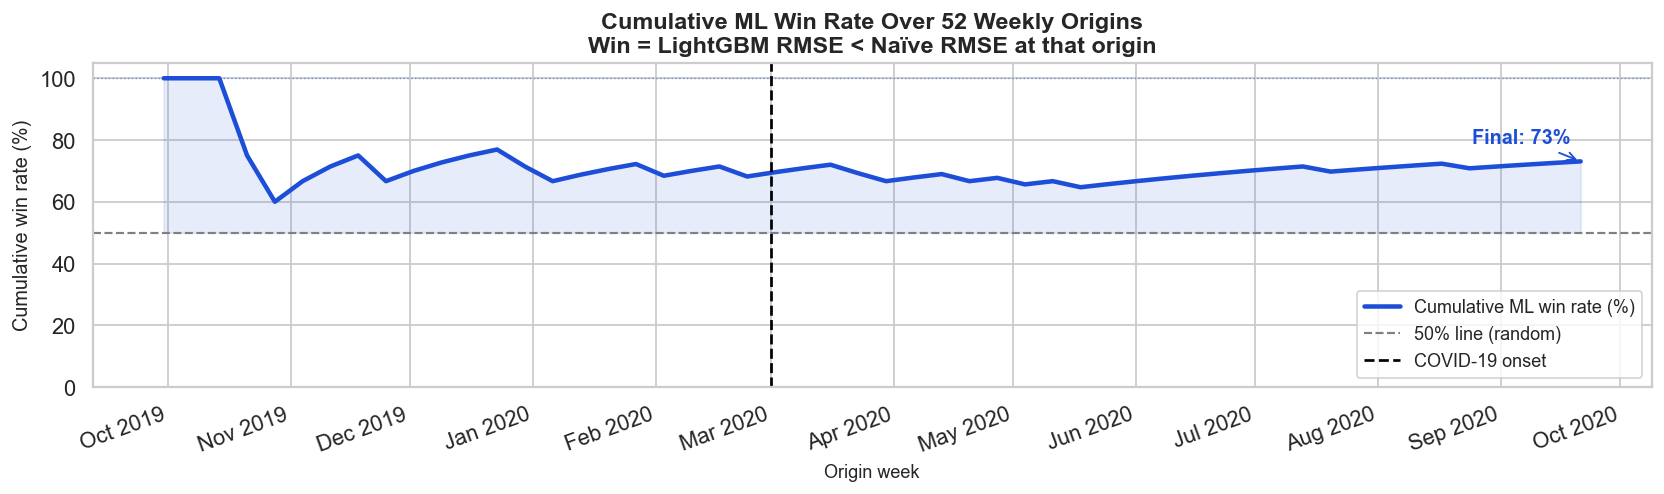

Saved: plots/rolling/R4_cumulative_win_rate.png


In [9]:
# ── Plot 4: Cumulative ML win rate over origins ────────────────────────────────
res_sorted = res.sort_values('origin').reset_index(drop=True)
cum_wins   = (res_sorted['RMSE_lgb'] < res_sorted['RMSE_naive']).cumsum()
cum_rate   = cum_wins / (res_sorted.index + 1) * 100

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(res_sorted['origin'], cum_rate, color='#1d4ed8', lw=2.5,
        label='Cumulative ML win rate (%)')
ax.fill_between(res_sorted['origin'], 50, cum_rate,
                where=cum_rate >= 50, alpha=0.1, color='#1d4ed8')
ax.fill_between(res_sorted['origin'], 50, cum_rate,
                where=cum_rate < 50, alpha=0.1, color='#dc2626')
ax.axhline(50, color='grey', lw=1.2, linestyle='--', label='50% line (random)')
ax.axhline(100, color='#1d4ed8', lw=0.8, linestyle=':', alpha=0.5)
ax.axvline(COVID_WEEK, color='black', lw=1.5, linestyle='--', label='COVID-19 onset')
ax.set_ylim(0, 105)
ax.set_ylabel('Cumulative win rate (%)', fontsize=11)
ax.set_xlabel('Origin week', fontsize=10)
ax.set_title('Cumulative ML Win Rate Over 52 Weekly Origins\n'
             'Win = LightGBM RMSE < Naïve RMSE at that origin',
             fontsize=13, fontweight='bold')
# Annotate final win rate
final_wr = cum_rate.iloc[-1]
ax.annotate(f'Final: {final_wr:.0f}%',
            xy=(res_sorted['origin'].iloc[-1], final_wr),
            xytext=(-60, 10), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#1d4ed8',
            arrowprops=dict(arrowstyle='->', color='#1d4ed8'))
ax.legend(fontsize=10, loc='lower right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plots/rolling/R4_cumulative_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/rolling/R4_cumulative_win_rate.png')


In [10]:
# ── Results table for thesis ──────────────────────────────────────────────────
summary_rows = []
for method, (rmse_col, mae_col, mape_col, color) in {
    'Naïve':                      ('RMSE_naive',   'MAE_naive',  'MAPE_naive',  '#dc2626'),
    'MA-4':                       ('RMSE_ma4',     None,         None,          '#f97316'),
    'Croston':                    ('RMSE_croston', None,         None,          '#9ca3af'),
    'LightGBM (rolling retrain)': ('RMSE_lgb',     'MAE_lgb',   'MAPE_lgb',    '#1d4ed8'),
}.items():
    r = res[rmse_col]
    row = {
        'Method':          method,
        'Mean RMSE':       round(r.mean(), 4),
        'Median RMSE':     round(r.median(), 4),
        'Std RMSE':        round(r.std(), 4),
        'Min RMSE':        round(r.min(), 4),
        'Max RMSE':        round(r.max(), 4),
    }
    if mae_col:
        row['Mean MAE']      = round(res[mae_col].mean(), 4)
        row['Mean NZ-MAPE']  = round(res[mape_col].mean(), 2)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Method')

print('='*90)
print('  ROLLING-ORIGIN SUMMARY TABLE')
print('='*90)
print(summary_df.to_string())
print()

# Δ table: vs Naïve
naive_mean = summary_df.loc['Naïve', 'Mean RMSE']
for method in ['MA-4', 'Croston', 'LightGBM (rolling retrain)']:
    delta = (summary_df.loc[method, 'Mean RMSE'] - naive_mean) / naive_mean * 100
    print(f'  {method:35s}  Δ mean RMSE vs Naïve: {delta:+.1f}%')

print(f'\n  LightGBM win rate across 52 origins: {lgb_win_rate:.0f}%')
print(f'  Pre-COVID win rate : {(res[~res["is_covid"]]["RMSE_lgb"] < res[~res["is_covid"]]["RMSE_naive"]).mean()*100:.0f}%')
print(f'  COVID period win rate: {(res[res["is_covid"]]["RMSE_lgb"] < res[res["is_covid"]]["RMSE_naive"]).mean()*100:.0f}%')

summary_df.to_csv(f'{BASE}/rolling_backtest_summary.csv')
print('\nSaved: rolling_backtest_summary.csv')


  ROLLING-ORIGIN SUMMARY TABLE
                            Mean RMSE  Median RMSE  Std RMSE  Min RMSE  Max RMSE  Mean MAE  Mean NZ-MAPE
Method                                                                                                  
Naïve                          5.7561       5.8127    2.3019    2.3514   12.2153    1.0683         89.20
MA-4                           6.7263       6.2608    2.3143    3.0578   14.3078       NaN           NaN
Croston                       10.0347       9.2309    3.1592    5.2954   19.2102       NaN           NaN
LightGBM (rolling retrain)     5.3238       5.1675    2.1798    2.1429   11.4395    0.9230         66.09

  MA-4                                 Δ mean RMSE vs Naïve: +16.9%
  Croston                              Δ mean RMSE vs Naïve: +74.3%
  LightGBM (rolling retrain)           Δ mean RMSE vs Naïve: -7.5%

  LightGBM win rate across 52 origins: 73%
  Pre-COVID win rate : 68%
  COVID period win rate: 77%

Saved: rolling_backtest_summary.cs